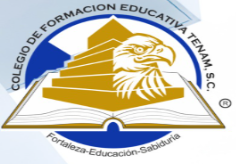

# Actividad Operaciones de nivel medio
## Universidad TENAM

**Docente:** DANIEL GONZÁLEZ SCARPULLI  
**Alumno:** Ismael Rufino Grajeda Marin

#### OPERACIONES MORFOLÓGICAS


error: pkg: please install the Debian package "octave-dev" to get the mkoctfile command
error: called from
    __gripe_missing_component__ at line 60 column 3
    configure_make at line 46 column 7
    install at line 204 column 7
    pkg at line 619 column 9
error: the following dependencies were unsatisfied:
   statistics needs octave >= 9.1.0
 statistics needs datatypes >= 1.2.0


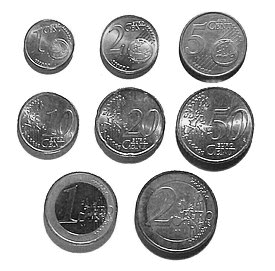

In [30]:
% Compatibilidad grafica con octave y jupiter  
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');
% paquete necesario para histeq
clc, clear, close all;
pkg install -forge io;
pkg install -forge statistics;

pkg load statistics;

I = imread('img/monedas5.jpg');
I = rgb2gray(I);
imshow(I)

% SE = strel(forma,parámetro)
se1 = strel('square',11); % Cuadrado 11x11
se2 = strel('line',10,45); % Línea de longitud 10 y ángulo de 45°
se3 = strel('disk',15,0); % Disco de radio 15
se4 = strel('ball',15,5); % Bola de radio 15 y alto 5

### Operaciones morfológicas

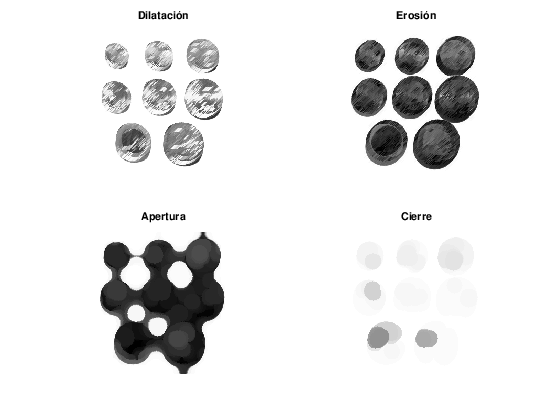

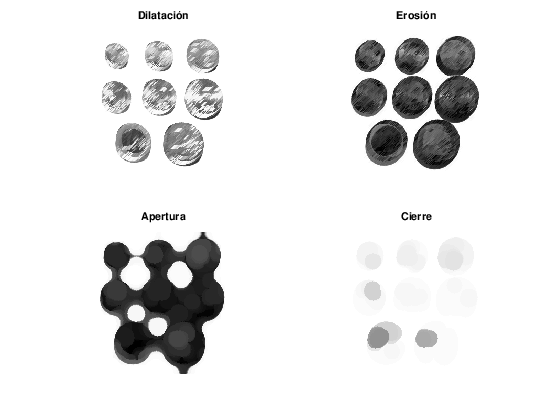

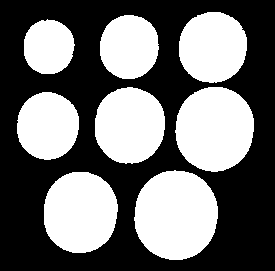

In [17]:


J1 = imdilate(I,se2); % Dilatación
J2 = imerode(I,se2); %Erosión
J3 = imopen(I,se3); %Apertura
J4 = imclose(I,se3); %Cierre
figure,
subplot(2,2,1), imshow(J1), title('Dilatación')
subplot(2,2,2), imshow(J2), title('Erosión')
subplot(2,2,3), imshow(J3), title('Apertura')
subplot(2,2,4), imshow(J4), title('Cierre')
BW = im2bw(I,0.6); % Binariza una imagen
BW = BW==0; %Inviertan
BW = imfill(BW,'holes'); % Rellena los agujeros
figure, imshow(BW)

### SEGMENTACIÓN

Número de monedas: 
8


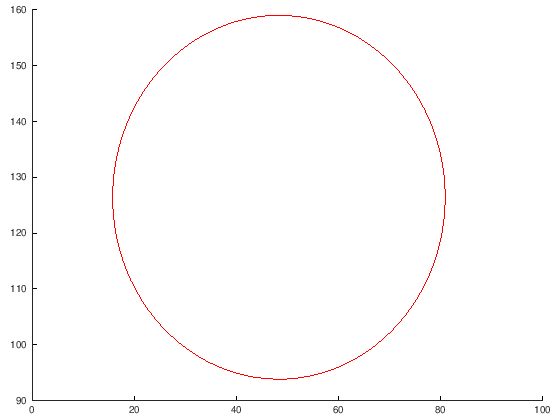

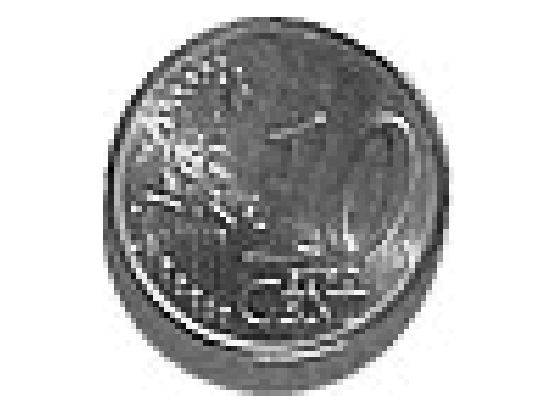

In [19]:
L = bwlabel(BW); % Crea regiones (etiqueta componentes conectados)
numele = max(max(L)); % Número de objetos etiquetados
disp('Número de monedas: '), disp(numele)
stats = regionprops(L,'all'); % Estadísticas de las regiones
% Coloca un círculo rojo al rededor de un elemento
figure(1); hold on
num = 1; center = stats(num).Centroid;
diametro = mean([stats(num).MajorAxisLength stats(num).MinorAxisLength],2);
radio = diametro/2;
viscircles(center,radio);
hold off
% Recortar el elemento
E = stats(1).BoundingBox; % Toma la frontera de la 1ra región
M1 = imcrop(I,E); % Devuelve la 1ra región
figure,
imshow(M1)

Mediante el uso de operaciones morfológicas, y la segmentacion, se puede hacer una deteccion de la cantidad de objetos en una imagen.

## 2 Segmentación basada en bordes

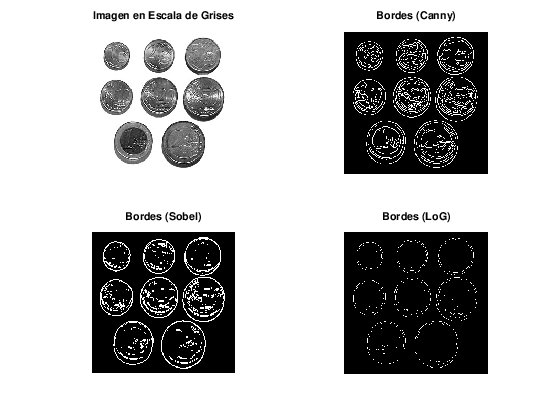

In [21]:
% Cargar la imagen de entrada
imagen = imread('img/monedas5.jpg');
% Convertir la imagen a escala de grises
imagen_grises = rgb2gray(imagen);
% Algoritmo de detección de bordes: Canny
bordes_canny = edge(imagen_grises, 'Canny');
% Algoritmo de detección de bordes: Sobel
filtro_sobel_x = [-1 0 1; -2 0 2; -1 0 1];
filtro_sobel_y = [-1 -2 -1; 0 0 0; 1 2 1];
gradiente_x = conv2(double(imagen_grises), filtro_sobel_x, 'same');
gradiente_y = conv2(double(imagen_grises), filtro_sobel_y, 'same');
magnitud_gradiente = sqrt(gradiente_x.^2 + gradiente_y.^2);
umbral_sobel = 0.3 * max(magnitud_gradiente(:));
bordes_sobel = magnitud_gradiente > umbral_sobel;
% Algoritmo de detección de bordes: Laplaciano de Gaussiano (LoG)
filtro_log = fspecial('log', [5 5], 2);
%bordes_log = edge(imagen_grises, 'log', 0, filtro_log);
bordes_log = edge(imagen_grises, 'log');
% Mostrar las imágenes de bordes resultantes
figure;
subplot(2, 2, 1);
imshow(imagen_grises);
title('Imagen en Escala de Grises');
subplot(2, 2, 2);
imshow(bordes_canny);
title('Bordes (Canny)');
subplot(2, 2, 3);
imshow(bordes_sobel);
title('Bordes (Sobel)');
subplot(2, 2, 4);
imshow(bordes_log);
title('Bordes (LoG)');

Mediante el uso de un filtro con mascaras que definan gradientes verticales y horizontales, se puede obtener una imagen con bordes resaltados.

### Segmentación basada en regiones

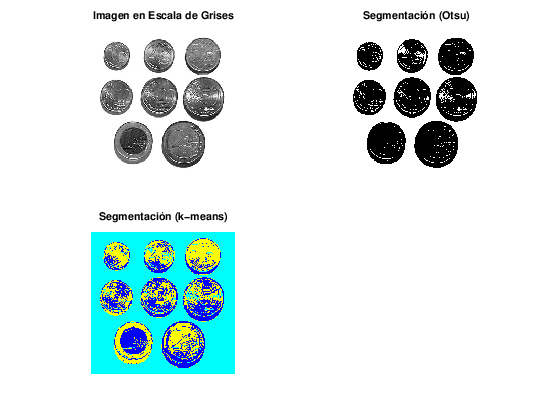

In [31]:
% Cargar la imagen de entrada
imagen = imread('img/monedas5.jpg');
% Convertir la imagen a escala de grises
imagen_grises = rgb2gray(imagen);
% Algoritmo de segmentación basado en umbralización global (Otsu)
umbral_otsu = graythresh(imagen_grises);
segmentacion_otsu = im2bw(imagen_grises, umbral_otsu);
% Algoritmo de segmentación basado en k-means
num_clusters = 3; % Número de clusters deseados
[filas, columnas] = size(imagen_grises);
X = reshape(double(imagen_grises), filas*columnas, 1);
[idx, centroides] = kmeans(X, num_clusters);
segmentacion_kmeans = reshape(idx, filas, columnas);
% Mostrar las imágenes de segmentación resultantes
figure;
subplot(2, 2, 1);
imshow(imagen_grises);
title('Imagen en Escala de Grises');
subplot(2, 2, 2);
imshow(segmentacion_otsu);
title('Segmentación (Otsu)');
subplot(2, 2, 3);
imshow(label2rgb(segmentacion_kmeans));
title('Segmentación (k-means)');



Umbralización Global (Otsu): Calcula un umbral óptimo para binarizar la imagen.
Agrupamiento (k-means): Clasifica los píxeles en 3 clusters según su intensidad de gris.


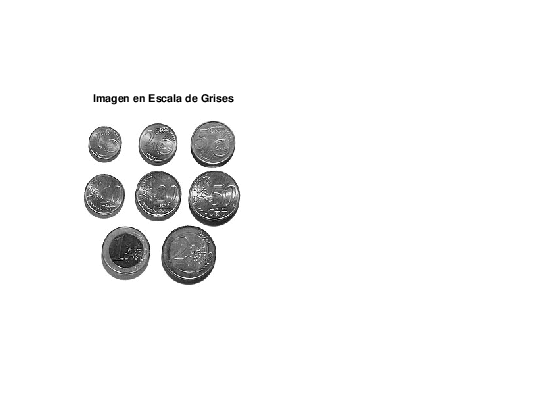

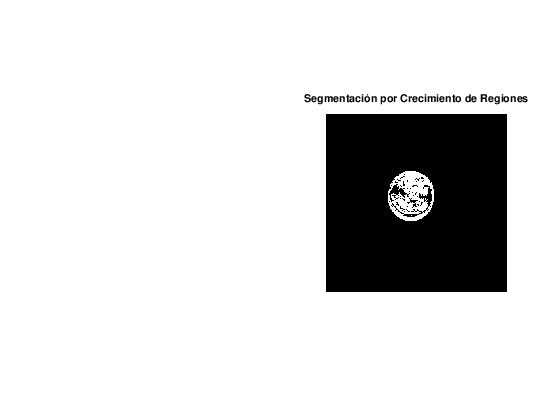

In [33]:
% Cargar la imagen de entrada
imagen = imread('img/monedas5.jpg');
% Convertir la imagen a escala de grises
imagen_grises = rgb2gray(imagen);
% Definir las coordenadas de la semilla de inicio
x = 100; % Ejemplo: coordenada x de la semilla
y = 150; % Ejemplo: coordenada y de la semilla
% Definir el umbral de crecimiento
valor_umbral = 20; % Ejemplo: umbral de crecimiento
% Aplicar el algoritmo de segmentación por crecimiento de regiones
segmentacion_crecimiento = regionGrowing(imagen_grises, [x, y], valor_umbral);
% Mostrar la imagen de segmentación por crecimiento de regiones
figure;
subplot(1, 2, 1);
imshow(imagen_grises);
title('Imagen en Escala de Grises');
figure;
subplot(1, 2, 2);
imshow(segmentacion_crecimiento);
title('Segmentación por Crecimiento de Regiones');
function segmentacion = regionGrowing(imagen_grises, semilla, umbral)
    [filas, columnas] = size(imagen_grises);
    visitados = false(filas, columnas);
    segmentacion = false(filas, columnas);
    cola = [];

    % Obtener la intensidad de la semilla
    intensidad_semilla = imagen_grises(semilla(1), semilla(2));

    % Agregar la semilla a la cola
    cola = [cola; semilla];

    while ~isempty(cola)
        % Sacar el primer píxel de la cola
        pixel_actual = cola(1, :);
        cola(1, :) = [];

        % Verificar si el píxel ya ha sido visitado
        if visitados(pixel_actual(1), pixel_actual(2))
            continue;
        end

        % Marcar el píxel como visitado
        visitados(pixel_actual(1), pixel_actual(2)) = true;

        % Verificar la diferencia de intensidad con la semilla
        if abs(imagen_grises(pixel_actual(1), pixel_actual(2)) -intensidad_semilla) <= umbral
            % Agregar el píxel a la segmentación
            segmentacion(pixel_actual(1), pixel_actual(2)) = true;

            % Agregar los píxeles vecinos a la cola
            vecinos = getNeighbors(pixel_actual, filas, columnas);
            cola = [cola; vecinos];
        end
    end
end
function vecinos = getNeighbors(pixel, filas, columnas)
    vecinos = [pixel(1)-1, pixel(2);
    pixel(1)+1, pixel(2);
    pixel(1), pixel(2)-1;
    pixel(1), pixel(2)+1];

    % Eliminar los vecinos fuera de los límites de la imagen
    vecinos(vecinos(:, 1) < 1 | vecinos(:, 1) > filas | vecinos(:, 2) < 1 |
vecinos(:, 2) > columnas, :) = [];
end

### Conclusiones de la Segmentación por Crecimiento de Regiones

1. **Dependencia de la Semilla:** La precisión del resultado está fuertemente ligada a la ubicación inicial de la semilla. Si el punto de inicio no es representativo de la región objetivo, la segmentación fallará en capturar el objeto completo.
2. **Sensibilidad al Umbral:** El parámetro `valor_umbral` es el factor determinante para la expansión. Un umbral muy pequeño resultará en una región fragmentada, mientras que un umbral demasiado alto provocará que la segmentación se desborde hacia el fondo u otros objetos.
3. **Garantía de Conectividad:** A diferencia de una umbralización global, este método asegura que la región resultante sea contigua (conectada), lo cual es fundamental para el análisis de formas y la extracción de objetos individuales.
4. **Eficacia en Imágenes Homogéneas:** El algoritmo es altamente efectivo para segmentar estructuras con niveles de gris uniformes que contrastan con su entorno, como las monedas en el ejemplo, permitiendo aislar elementos específicos de manera precisa.
5. **Simplicidad y Control:** El uso de una cola para la gestión de vecinos (vecindad de 4) permite un control iterativo del proceso de crecimiento, facilitando la implementación de criterios adicionales de parada si fuera necesario.
```
